<a href="https://colab.research.google.com/github/swaroopgelye/Data_Science_lab_SE_A15/blob/main/Exp_08.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd

# Load the datasets
ratings_df = pd.read_csv('/content/rating.csv')
movies_df = pd.read_csv('/content/movie.csv')

### Ratings Data

In [8]:
print('Ratings DataFrame Info:')
display(ratings_df.head())
print('\nRatings DataFrame Description:')
display(ratings_df.describe())
print('\nRatings DataFrame Missing Values:')
display(ratings_df.isnull().sum())

Ratings DataFrame Info:


,userId,movieId,rating,timestamp
0,1,2,3.5,2005-04-02 23:53:47
1,1,29,3.5,2005-04-02 23:31:16
2,1,32,3.5,2005-04-02 23:33:39
3,1,47,3.5,2005-04-02 23:32:07
4,1,50,3.5,2005-04-02 23:29:40



Ratings DataFrame Description:


,userId,movieId,rating
count,1.153340e+07,1.153340e+07,1.153340e+07
mean,3.969727e+04,9.082706e+03,3.525575e+00
std,2.309792e+04,1.983193e+04,1.052128e+00
min,1.000000e+00,1.000000e+00,5.000000e-01
25%,1.956500e+04,9.040000e+02,3.000000e+00
50%,3.966700e+04,2.174000e+03,3.500000e+00
75%,5.974500e+04,4.816000e+03,4.000000e+00
max,7.960300e+04,1.312600e+05,5.000000e+00



Ratings DataFrame Missing Values:


,0
userId,0
movieId,0
rating,0
timestamp,0


### Movies Data

In [9]:
print('Movies DataFrame Info:')
display(movies_df.head())
print('\nMovies DataFrame Description:')
display(movies_df.describe())
print('\nMovies DataFrame Missing Values:')
display(movies_df.isnull().sum())

Movies DataFrame Info:


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy



Movies DataFrame Description:


,movieId
count,27278.000000
mean,59855.480570
std,44429.314697
min,1.000000
25%,6931.250000
50%,68068.000000
75%,100293.250000
max,131262.000000



Movies DataFrame Missing Values:


,0
movieId,0
title,0
genres,0


### Merging DataFrames and Feature Engineering

In [10]:
# Merge ratings and movies DataFrames
merged_df = pd.merge(ratings_df, movies_df, on='movieId', how='left')

# Define target variable: high vs. low rating (e.g., >= 3.5 as high)
merged_df['is_high_rating'] = (merged_df['rating'] >= 3.5).astype(int)

print('Merged DataFrame Info:')
display(merged_df.head())
print('\nDistribution of High Ratings:')
display(merged_df['is_high_rating'].value_counts())
print('\nMissing values in Merged DataFrame:')
display(merged_df.isnull().sum())

Merged DataFrame Info:


,userId,movieId,rating,timestamp,title,genres,is_high_rating
0,1,2,3.5,2005-04-02 23:53:47,Jumanji (1995),Adventure|Children|Fantasy,1
1,1,29,3.5,2005-04-02 23:31:16,"City of Lost Children, The (Cité des enfants p...",Adventure|Drama|Fantasy|Mystery|Sci-Fi,1
2,1,32,3.5,2005-04-02 23:33:39,Twelve Monkeys (a.k.a. 12 Monkeys) (1995),Mystery|Sci-Fi|Thriller,1
3,1,47,3.5,2005-04-02 23:32:07,Seven (a.k.a. Se7en) (1995),Mystery|Thriller,1
4,1,50,3.5,2005-04-02 23:29:40,"Usual Suspects, The (1995)",Crime|Mystery|Thriller,1



Distribution of High Ratings:


,count
is_high_rating,
1,7036248
0,4497157



Missing values in Merged DataFrame:


,0
userId,0
movieId,0
rating,0
timestamp,0
title,0
genres,0
is_high_rating,0


In [ ]:
print('Full Missing values in Merged DataFrame:')
display(merged_df.isnull().sum())

/tmp/ipykernel_19636/3235396158.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=genres_series, order=genres_series.value_counts().index, palette='magma')


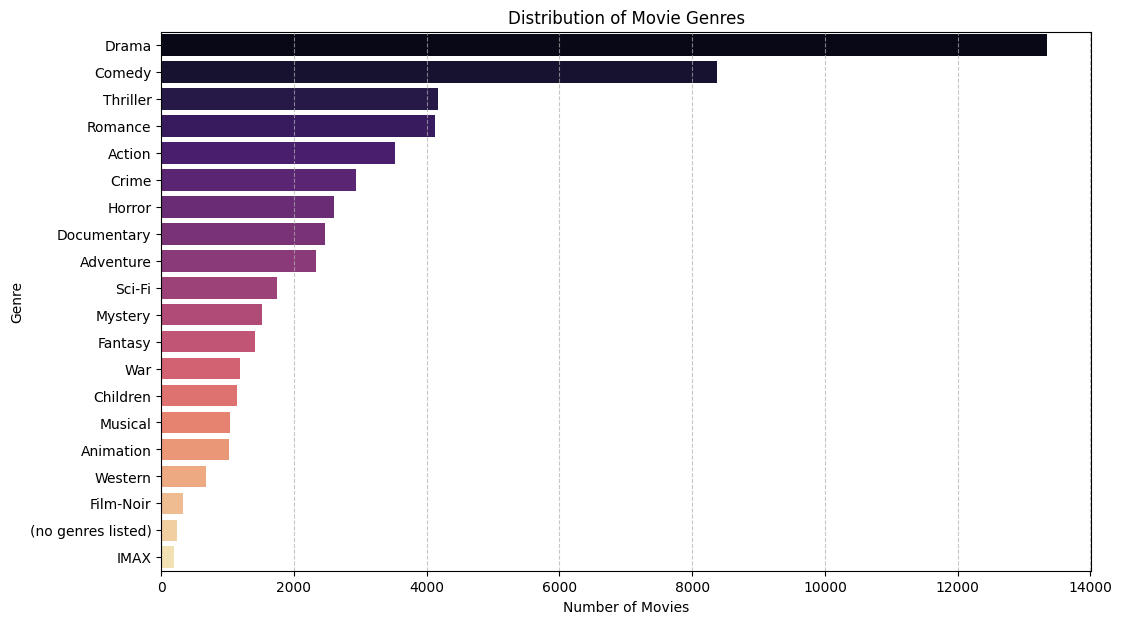

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Split genres and count occurrences
genres_flat = [genre for sublist in movies_df['genres'].str.split('|') for genre in sublist]
genres_series = pd.Series(genres_flat)

plt.figure(figsize=(12, 7))
sns.countplot(y=genres_series, order=genres_series.value_counts().index, palette='magma')
plt.title('Distribution of Movie Genres')
plt.xlabel('Number of Movies')
plt.ylabel('Genre')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

/tmp/ipykernel_19636/2013896648.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating', data=ratings_df, palette='viridis')


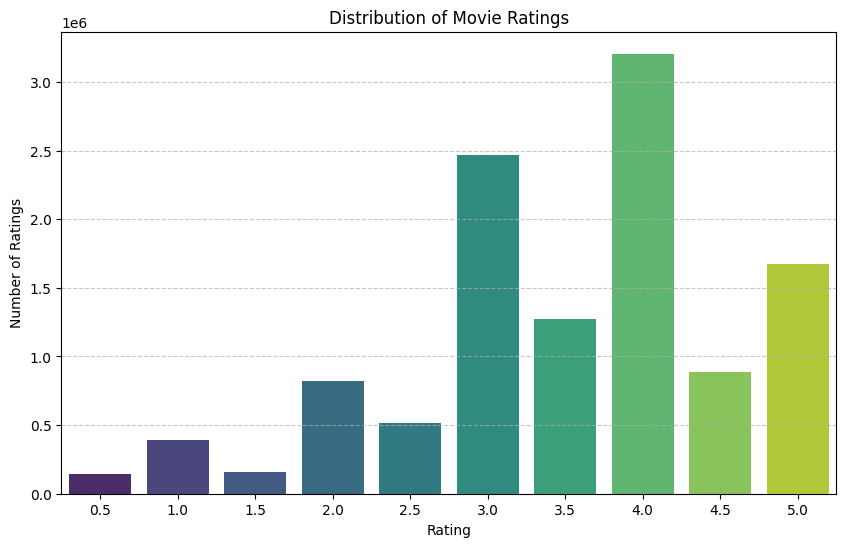

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.countplot(x='rating', data=ratings_df, palette='viridis')
plt.title('Distribution of Movie Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Ratings')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()